In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
model_df = pd.read_csv(
    "../data/processed/model_data.csv"
)

model_df["Date"] = pd.to_datetime(model_df["Date"])

print("Shape:", model_df.shape)
print("Date range:", model_df["Date"].min(), "to", model_df["Date"].max())

Shape: (983759, 22)
Date range: 2013-01-31 00:00:00 to 2015-07-31 00:00:00


In [5]:
print("Columns:")
print(model_df.columns.tolist())

print("\nMissing values:")
print(model_df.isnull().sum().sum())

print("\nTarget statistics:")
print(model_df["Sales"].describe())

Columns:
['Date', 'Store', 'DayOfWeek', 'Month', 'Year', 'WeekOfYear', 'IsWeekend', 'Promo', 'SchoolHoliday', 'StateHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Lag_30', 'Sales_Rolling_7', 'Sales_Rolling_14', 'Sales_Rolling_30', 'Sales_Rolling_7_Std', 'Sales']

Missing values:
0

Target statistics:
count    983759.000000
mean       5794.216983
std        3860.599343
min           0.000000
25%        3745.000000
50%        5765.000000
75%        7881.000000
max       41551.000000
Name: Sales, dtype: float64


In [6]:
train_df = model_df[
    model_df["Date"] < "2015-01-01"
].copy()

valid_df = model_df[
    model_df["Date"] >= "2015-01-01"
].copy()

print("Training rows:", len(train_df))
print("Validation rows:", len(valid_df))

print("\nTraining period:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nValidation period:")
print(valid_df["Date"].min(), "to", valid_df["Date"].max())

Training rows: 747379
Validation rows: 236380

Training period:
2013-01-31 00:00:00 to 2014-12-31 00:00:00

Validation period:
2015-01-01 00:00:00 to 2015-07-31 00:00:00


In [8]:
X_train = train_df.drop(columns=["Date", "Sales"])
y_train = train_df["Sales"]

X_valid = valid_df.drop(columns=["Date", "Sales"])
y_valid = valid_df["Sales"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train: (747379, 20)
y_train: (747379,)
X_valid: (236380, 20)
y_valid: (236380,)


In [9]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "StateHoliday",
    "StoreType",
    "Assortment"
]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_valid_cat = encoder.transform(
    X_valid[categorical_features]
)

X_train_num = X_train[numeric_features].values
X_valid_num = X_valid[numeric_features].values

X_train_encoded = np.hstack([
    X_train_num,
    X_train_cat
])

X_valid_encoded = np.hstack([
    X_valid_num,
    X_valid_cat
])

print("Original features:", X_train.shape[1])
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_valid_encoded.shape)

Original features: 20
Encoded training shape: (747379, 28)
Encoded validation shape: (236380, 28)


In [10]:
baseline_prediction = np.full(
    len(y_valid),
    y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_valid,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_valid,
    baseline_prediction
)

print("BASELINE MODEL")
print("------------------------")
print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²  :", round(baseline_r2, 4))

BASELINE MODEL
------------------------
MAE : 2889.91
RMSE: 3841.78
R²  : -0.0008


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(
    X_train_encoded,
    y_train
)

print("Training completed.")
print("Number of trees:", len(rf_model.estimators_))

Training Random Forest...
Training completed.
Number of trees: 50


In [16]:
rf_predictions = rf_model.predict(X_valid_encoded)

rf_mae = mean_absolute_error(
    y_valid,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_valid,
    rf_predictions
)

print("RANDOM FOREST")
print("------------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

print("\nBASELINE")
print("------------------------")
print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²  :", round(baseline_r2, 4))

RANDOM FOREST
------------------------
MAE : 565.43
RMSE: 944.39
R²  : 0.9395

BASELINE
------------------------
MAE : 2889.91
RMSE: 3841.78
R²  : -0.0008


In [17]:
feature_names = (
    numeric_features +
    list(encoder.get_feature_names_out(categorical_features))
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(feature_importance.head(15))

                Feature  Importance
0          Sales_Lag_14    0.529099
1             DayOfWeek    0.157093
2        StateHoliday_0    0.098337
3           Sales_Lag_1    0.054051
4      Sales_Rolling_14    0.032839
5                 Promo    0.031594
6       Sales_Rolling_7    0.027684
7      Sales_Rolling_30    0.025682
8           Sales_Lag_7    0.011364
9   Sales_Rolling_7_Std    0.009881
10           WeekOfYear    0.009471
11          StoreType_b    0.003829
12         Sales_Lag_30    0.002181
13                Month    0.001740
14            IsWeekend    0.001417


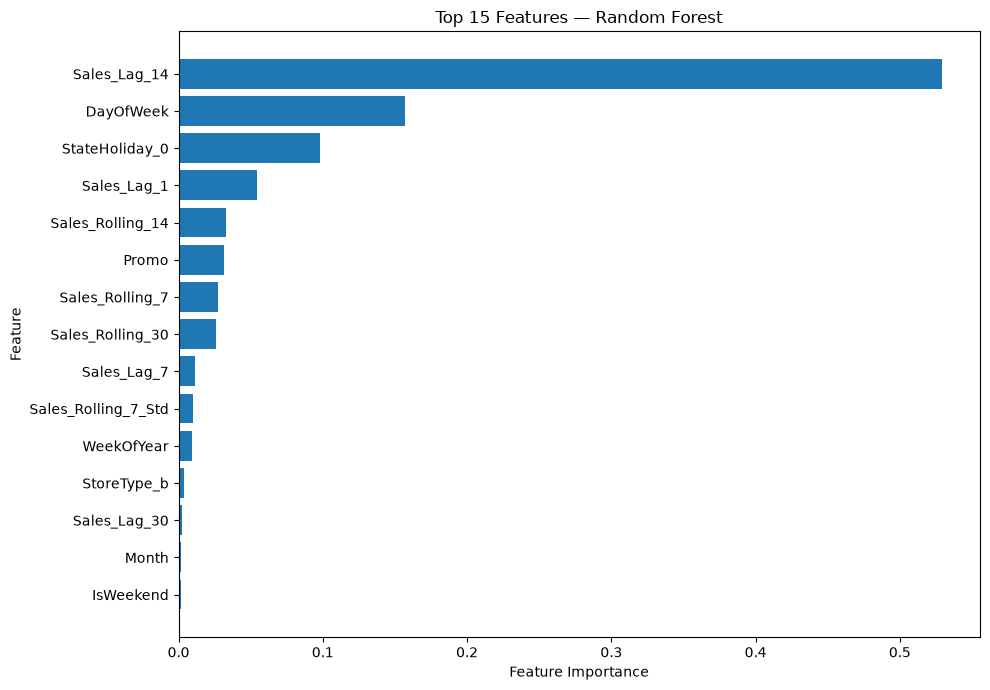

In [18]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Random Forest")

plt.tight_layout()
plt.show()

In [21]:
import xgboost as xgb

In [25]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

print("Training XGBoost...")

xgb_model.fit(
    X_train_encoded,
    y_train,
    verbose=False
)

print("Training completed.")
print("Number of boosting rounds:", xgb_model.get_booster().num_boosted_rounds())

Training XGBoost...
Training completed.
Number of boosting rounds: 200


In [26]:
xgb_predictions = xgb_model.predict(X_valid_encoded)

xgb_mae = mean_absolute_error(
    y_valid,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_valid,
    xgb_predictions
)

print("XGBOOST")
print("------------------------")
print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R²  :", round(xgb_r2, 4))

XGBOOST
------------------------
MAE : 557.87
RMSE: 899.52
R²  : 0.9451


In [27]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost"],
    "MAE": [baseline_mae, rf_mae, xgb_mae],
    "RMSE": [baseline_rmse, rf_rmse, xgb_rmse],
    "R2": [baseline_r2, rf_r2, xgb_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline,2889.907508,3841.781417,-0.000830
1,Random Forest,565.432270,944.393390,0.939522
2,XGBoost,557.865356,899.521852,0.945132


In [28]:
results = valid_df[["Date", "Store", "Sales"]].copy()

results["Predicted_Sales"] = xgb_predictions

results["Absolute_Error"] = abs(
    results["Sales"] - results["Predicted_Sales"]
)

results.head()

,Date,Store,Sales,Predicted_Sales,Absolute_Error
700,2015-01-01,1,0,-254.103043,254.103043
701,2015-01-02,1,5509,5391.116211,117.883789
702,2015-01-03,1,5023,5414.462402,391.462402
703,2015-01-04,1,0,-35.357002,35.357002
704,2015-01-05,1,6239,8423.279297,2184.279297


In [29]:
store_performance = results.groupby("Store").agg(
    Actual_Sales=("Sales", "sum"),
    Predicted_Sales=("Predicted_Sales", "sum"),
    Avg_Error=("Absolute_Error", "mean")
).reset_index()

store_performance["Error_%"] = (
    store_performance["Avg_Error"] /
    store_performance["Actual_Sales"] * 100
)

store_performance.sort_values(
    "Avg_Error",
    ascending=False
).head(10)

,Store,Actual_Sales,Predicted_Sales,Avg_Error,Error_%
908,909,1870735,1880901.000,1895.030896,0.101299
841,842,3476494,3443365.000,1870.955001,0.053817
643,644,1503204,1554946.250,1845.301740,0.122758
261,262,4412501,4360879.000,1546.877713,0.035057
875,876,1550092,1584624.375,1476.622425,0.095260
673,674,1224751,1302891.500,1399.666973,0.114282
755,756,2958278,2991704.250,1345.399921,0.045479
826,827,2514170,2487274.000,1324.204941,0.052670
1113,1114,3809075,3740483.000,1293.424964,0.033956
334,335,2942498,2950901.250,1290.477985,0.043857


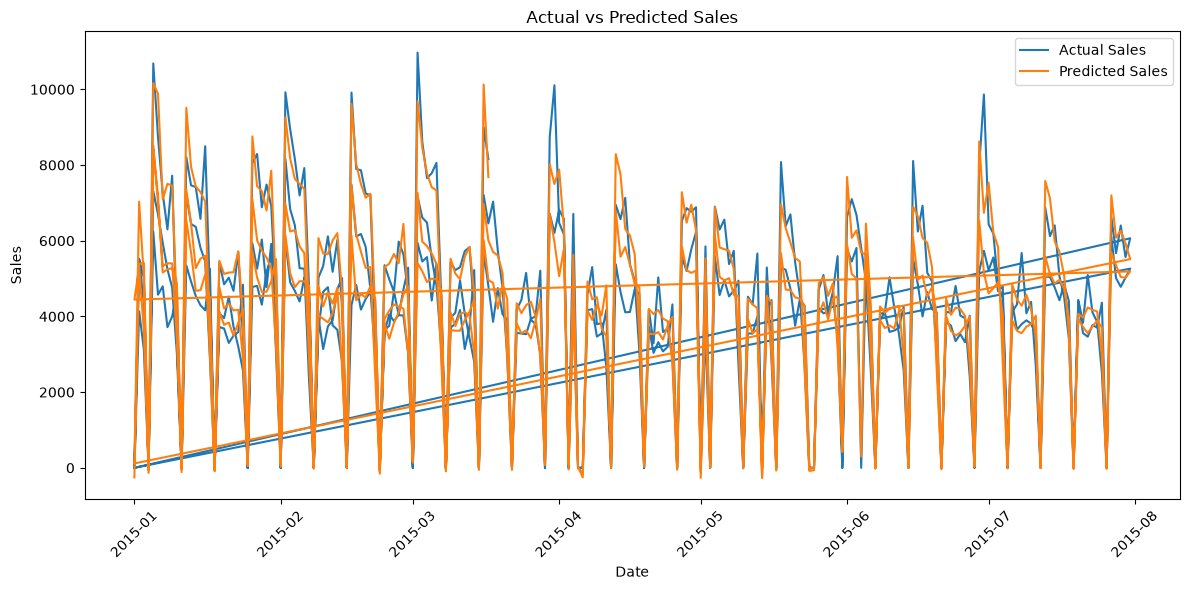

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    results["Date"].iloc[:500],
    results["Sales"].iloc[:500],
    label="Actual Sales"
)

plt.plot(
    results["Date"].iloc[:500],
    results["Predicted_Sales"].iloc[:500],
    label="Predicted Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

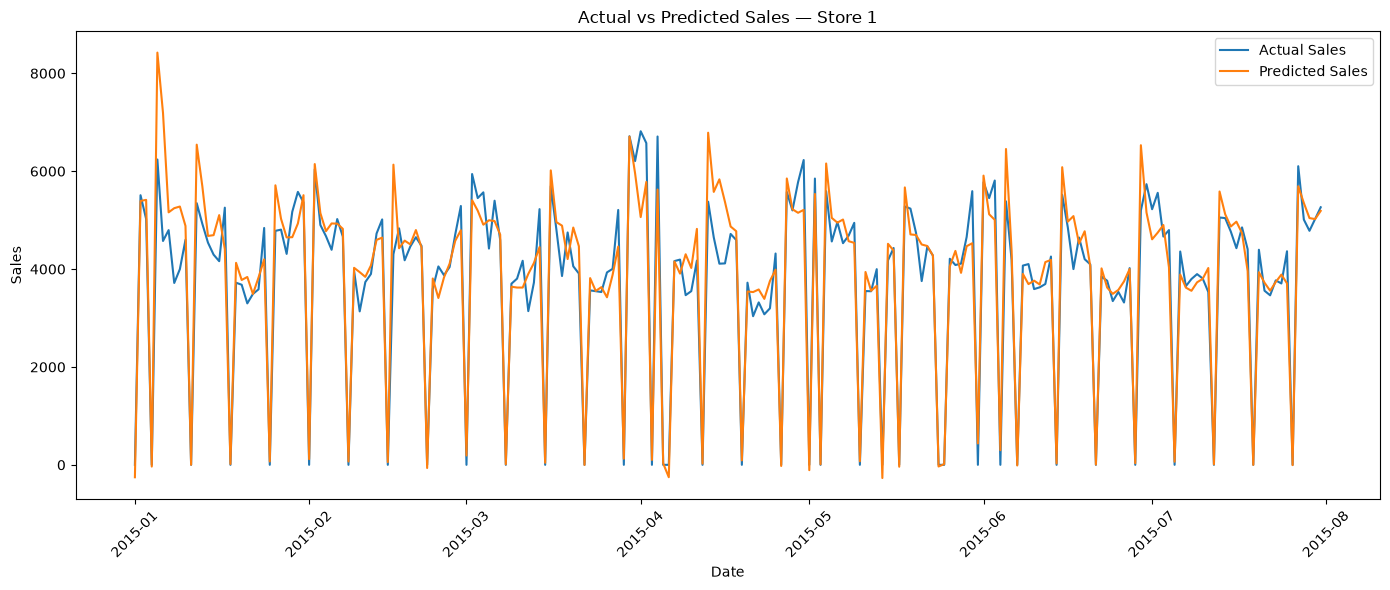

In [31]:
store_id = 1

store_results = results[
    results["Store"] == store_id
].copy()

plt.figure(figsize=(14, 6))

plt.plot(
    store_results["Date"],
    store_results["Sales"],
    label="Actual Sales"
)

plt.plot(
    store_results["Date"],
    store_results["Predicted_Sales"],
    label="Predicted Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title(f"Actual vs Predicted Sales — Store {store_id}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
promo_analysis = valid_df.groupby("Promo")["Sales"].agg(
    ["count", "mean", "sum"]
).reset_index()

promo_analysis

,Promo,count,mean,sum
0,0,141605,4454.209908,630738394
1,1,94775,8005.921910,758761249


In [33]:
store_promo = valid_df.groupby(
    ["Store", "Promo"]
)["Sales"].mean().unstack()

store_promo["Difference_%"] = (
    (store_promo[1] - store_promo[0])
    / store_promo[0]
) * 100

store_promo.sort_values(
    "Difference_%",
    ascending=False
).head(10)

Promo,0,1,Difference_%
Store,,,
198,1244.929134,3957.305882,217.873988
607,1794.527559,5057.329412,181.819546
543,1329.062992,3693.282353,177.886178
575,2713.362205,7320.329412,169.788140
271,4146.346457,10857.011765,161.845263
693,3392.968504,8750.482353,157.900489
286,2317.511811,5910.329412,155.029096
898,3432.527559,8753.282353,155.009820
552,3932.354331,10027.482353,154.999461


In [34]:
store_promo_counts = valid_df.groupby(
    ["Store", "Promo"]
).size().unstack(fill_value=0)

store_promo_counts.columns = [
    "Non_Promo_Days",
    "Promo_Days"
]

store_promo_counts.head(10)

,Non_Promo_Days,Promo_Days
Store,,
1,127,85
2,127,85
3,127,85
4,127,85
5,127,85
6,127,85
7,127,85
8,127,85
9,127,85


In [35]:
store_promo_analysis = store_promo.join(
    store_promo_counts
)

store_promo_analysis.head(10)

,0,1,Difference_%,Non_Promo_Days,Promo_Days
Store,,,,,
1,3003.913386,4833.047059,60.891692,127,85
2,2814.125984,6139.623529,118.171594,127,85
3,3950.503937,8298.035294,110.050045,127,85
4,6593.385827,10523.423529,59.605760,127,85
5,2526.984252,5825.858824,130.545909,127,85
6,2784.519685,5690.329412,104.355869,127,85
7,5486.692913,10377.388235,89.137398,127,85
8,3605.960630,7681.611765,113.025392,127,85
9,4759.874016,8412.329412,76.734287,127,85


In [36]:
day_analysis = valid_df.groupby("DayOfWeek")["Sales"].agg(
    ["count", "mean", "sum"]
).reset_index()

day_analysis

,DayOfWeek,count,mean,sum
0,1,33450,7757.710224,259495407
1,2,33450,7196.034888,240707367
2,3,33450,6923.930045,231605460
3,4,34565,6330.986894,218830562
4,5,34565,6655.121250,230034266
5,6,33450,6029.252078,201678482
6,7,33450,213.695037,7148099


In [37]:
day_analysis["Day"] = day_analysis["DayOfWeek"].map({
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
})

day_analysis[
    ["DayOfWeek", "Day", "count", "mean", "sum"]
]

,DayOfWeek,Day,count,mean,sum
0,1,Monday,33450,7757.710224,259495407
1,2,Tuesday,33450,7196.034888,240707367
2,3,Wednesday,33450,6923.930045,231605460
3,4,Thursday,34565,6330.986894,218830562
4,5,Friday,34565,6655.121250,230034266
5,6,Saturday,33450,6029.252078,201678482
6,7,Sunday,33450,213.695037,7148099


In [38]:
sunday_analysis = valid_df[valid_df["DayOfWeek"] == 7].copy()

print("Total Sunday rows:", len(sunday_analysis))

print(
    "Sunday zero-sales rows:",
    (sunday_analysis["Sales"] == 0).sum()
)

print(
    "Sunday zero-sales %:",
    (sunday_analysis["Sales"] == 0).mean() * 100
)

Total Sunday rows: 33450
Sunday zero-sales rows: 32628
Sunday zero-sales %: 97.54260089686099


In [39]:
sunday_by_store = sunday_analysis.groupby("Store")["Sales"].agg(
    ["count", "mean", "sum"]
).reset_index()

sunday_by_store.sort_values(
    "mean",
    ascending=True
).head(10)

,Store,count,mean,sum
15,16,30,0.0,0
17,18,30,0.0,0
18,19,30,0.0,0
19,20,30,0.0,0
20,21,30,0.0,0
21,22,30,0.0,0
22,23,30,0.0,0
23,24,30,0.0,0
24,25,30,0.0,0
25,26,30,0.0,0


In [40]:
monthly_sales = valid_df.copy()

monthly_sales["YearMonth"] = (
    monthly_sales["Date"].dt.to_period("M")
)

monthly_sales = monthly_sales.groupby(
    "YearMonth"
)["Sales"].agg(
    ["mean", "sum"]
).reset_index()

monthly_sales

,YearMonth,mean,sum
0,2015-01,5752.747866,198843730
1,2015-02,5710.296541,178275458
2,2015-03,5949.130132,205631683
3,2015-04,5916.857578,197918886
4,2015-05,5472.122002,189143897
5,2015-06,6199.203976,207363373
6,2015-07,6142.705511,212322616


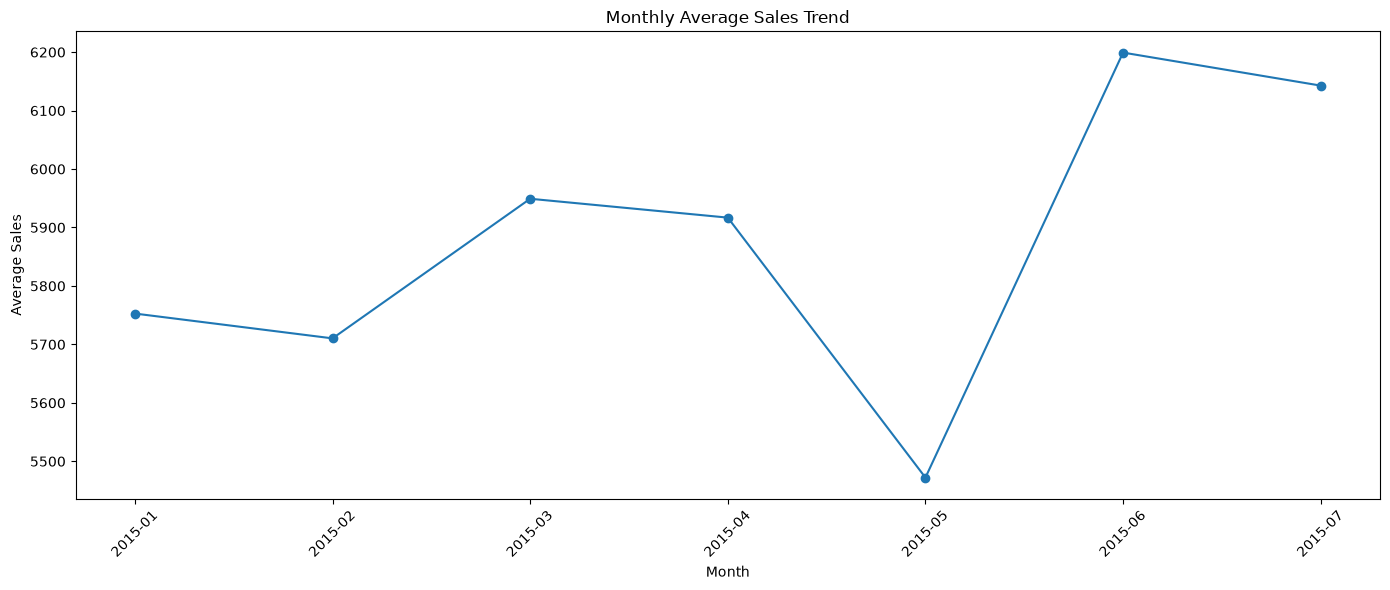

In [41]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["YearMonth"].astype(str),
    monthly_sales["mean"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.title("Monthly Average Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
store_sales = valid_df.groupby("Store")["Sales"].agg(
    ["count", "mean", "sum"]
).reset_index()

store_sales = store_sales.rename(columns={
    "count": "Days",
    "mean": "Average_Sales",
    "sum": "Total_Sales"
})

store_sales.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

,Store,Days,Average_Sales,Total_Sales
261,262,212,20813.683962,4412501
561,562,212,17986.740566,3813189
1113,1114,212,17967.334906,3809075
816,817,212,16784.995283,3558419
841,842,212,16398.556604,3476494
250,251,212,15986.929245,3389229
732,733,212,15236.174528,3230069
787,788,212,15086.033019,3198239
512,513,212,14618.674528,3099159
382,383,212,14069.254717,2982682


In [43]:
store_sales.sort_values(
    "Total_Sales",
    ascending=True
).head(10)

,Store,Days,Average_Sales,Total_Sales
306,307,212,2214.617925,469499
840,841,212,2259.726415,479062
542,543,212,2276.981132,482720
197,198,212,2332.438679,494477
207,208,212,2502.443396,530518
969,970,212,2606.042453,552481
218,219,212,2615.811321,554552
557,558,212,2634.004717,558409
434,435,212,2638.344340,559329
253,254,212,2645.830189,560916


In [44]:
store_predictions = results.groupby("Store").agg(
    Actual_Avg_Sales=("Sales", "mean"),
    Predicted_Avg_Sales=("Predicted_Sales", "mean")
).reset_index()

store_predictions["Prediction_Gap"] = (
    store_predictions["Predicted_Avg_Sales"]
    - store_predictions["Actual_Avg_Sales"]
)

store_predictions.head()

,Store,Actual_Avg_Sales,Predicted_Avg_Sales,Prediction_Gap
0,1,3737.292453,3833.800293,96.507840
1,2,4147.462264,4203.291992,55.829728
2,3,5693.617925,5687.903320,-5.714604
3,4,8169.108491,8201.350586,32.242095
4,5,3849.646226,3883.918945,34.272719


In [45]:
store_predictions["Gap_%"] = (
    store_predictions["Prediction_Gap"]
    / store_predictions["Actual_Avg_Sales"]
) * 100

store_predictions.head()

,Store,Actual_Avg_Sales,Predicted_Avg_Sales,Prediction_Gap,Gap_%
0,1,3737.292453,3833.800293,96.507840,2.582293
1,2,4147.462264,4203.291992,55.829728,1.346118
2,3,5693.617925,5687.903320,-5.714604,-0.100369
3,4,8169.108491,8201.350586,32.242095,0.394683
4,5,3849.646226,3883.918945,34.272719,0.890282


In [46]:
def classify_prediction_gap(gap):
    if gap <= -10:
        return "UNDER_PREDICTION"
    elif gap >= 10:
        return "OVER_PREDICTION"
    else:
        return "NORMAL"


store_predictions["Decision"] = (
    store_predictions["Gap_%"]
    .apply(classify_prediction_gap)
)

store_predictions.head(10)

,Store,Actual_Avg_Sales,Predicted_Avg_Sales,Prediction_Gap,Gap_%,Decision
0,1,3737.292453,3833.800293,96.507840,2.582293,NORMAL
1,2,4147.462264,4203.291992,55.829728,1.346118,NORMAL
2,3,5693.617925,5687.903320,-5.714604,-0.100369,NORMAL
3,4,8169.108491,8201.350586,32.242095,0.394683,NORMAL
4,5,3849.646226,3883.918945,34.272719,0.890282,NORMAL
5,6,3949.584906,3969.631104,20.046198,0.507552,NORMAL
6,7,7447.584906,7399.059082,-48.525824,-0.651565,NORMAL
7,8,5240.066038,5204.156738,-35.909299,-0.685283,NORMAL
8,9,6224.301887,6259.995117,35.693230,0.573450,NORMAL
9,10,4834.113208,4838.402832,4.289624,0.088737,NORMAL


In [47]:
decision_summary = (
    store_predictions["Decision"]
    .value_counts()
    .reset_index()
)

decision_summary.columns = ["Decision", "Store_Count"]

decision_summary

,Decision,Store_Count
0,NORMAL,1114
1,OVER_PREDICTION,1


In [48]:
flagged_stores = store_predictions[
    store_predictions["Decision"] != "NORMAL"
].copy()

flagged_stores

,Store,Actual_Avg_Sales,Predicted_Avg_Sales,Prediction_Gap,Gap_%,Decision
197,198,2332.438679,2579.592773,247.154094,10.596381,OVER_PREDICTION


In [49]:
print("Flagged stores:", len(flagged_stores))

if len(flagged_stores) > 0:
    print(
        "Largest absolute gap:",
        flagged_stores["Gap_%"].abs().max()
    )

Flagged stores: 1
Largest absolute gap: 10.596381220714015


In [50]:
decision_output = store_predictions[
    [
        "Store",
        "Actual_Avg_Sales",
        "Predicted_Avg_Sales",
        "Gap_%",
        "Decision"
    ]
].copy()

decision_output = decision_output.sort_values(
    "Gap_%",
    ascending=False
).reset_index(drop=True)

decision_output.head(10)

,Store,Actual_Avg_Sales,Predicted_Avg_Sales,Gap_%,Decision
0,198,2332.438679,2579.592773,10.596381,OVER_PREDICTION
1,674,5777.127358,6145.714844,6.380117,NORMAL
2,607,3102.726415,3263.747070,5.189650,NORMAL
3,307,2214.617925,2329.377686,5.181921,NORMAL
4,970,2606.042453,2727.533691,4.661906,NORMAL
5,72,3680.617925,3838.149414,4.280028,NORMAL
6,897,2850.504717,2967.894531,4.118212,NORMAL
7,242,3356.113208,3491.397949,4.030995,NORMAL
8,977,3781.386792,3933.792725,4.030424,NORMAL
9,183,4070.014151,4233.855469,4.025571,NORMAL


In [51]:
decision_output["Decision"].value_counts()

Decision
NORMAL             1114
OVER_PREDICTION       1
Name: count, dtype: int64

In [58]:
import joblib

joblib.dump(
    xgb_model,
    "../decision_engine/xgb_sales_model.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


In [64]:
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

print("Encoded categorical features:")
print(encoded_feature_names)

Encoded categorical features:
['StateHoliday_0' 'StateHoliday_a' 'StateHoliday_b' 'StateHoliday_c'
 'StoreType_a' 'StoreType_b' 'StoreType_c' 'StoreType_d' 'Assortment_a'
 'Assortment_b' 'Assortment_c']


In [65]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
).tolist()

all_feature_names = numeric_features + encoded_feature_names

print("Total features:", len(all_feature_names))
print(all_feature_names)

Total features: 28
['Store', 'DayOfWeek', 'Month', 'Year', 'WeekOfYear', 'IsWeekend', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Lag_30', 'Sales_Rolling_7', 'Sales_Rolling_14', 'Sales_Rolling_30', 'Sales_Rolling_7_Std', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c']


In [66]:
joblib.dump(
    all_feature_names,
    "../decision_engine/xgb_feature_columns.pkl"
)

print("Feature columns saved successfully.")

Feature columns saved successfully.
